In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [32]:
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    category: str

In [ ]:
# Define Node Functions
def calculateBMI(state: BMIState):
    height = state["height_m"]
    weight = state["weight_kg"]

    bmi = weight/(height**2)

    state["bmi"] = round(bmi, 2)

    return state

In [45]:
def label_bmi(state: BMIState):
    bmi = state["bmi"]

    if bmi <= 18.4:
        state["category"] = "Underweight"
    elif bmi >= 18.5 and bmi <= 24.9:
        state["category"] = "Healthy weight"
    else:
        state["category"] = "Overweight"

    return state

In [46]:
# Construct Graph Layout
workflow = StateGraph(BMIState)

In [47]:
# Define Nodes
workflow.add_node("calculateBMI", calculateBMI)
workflow.add_node("label_bmi", label_bmi)

In [48]:
# Define edge

workflow.add_edge(START, "calculateBMI")
workflow.add_edge("calculateBMI", "label_bmi")
workflow.add_edge("label_bmi", END)

In [49]:
# Compile Graph
app = workflow.compile()

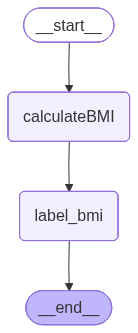

In [50]:
app

In [52]:
# Invoke and Run Graph
initial_input = {"height_m": 1.65, "weight_kg": 47}
final_state = app.invoke(initial_input)

In [53]:
print(final_state["height_m"], final_state["weight_kg"], final_state["bmi"], final_state["category"], sep="\n")

1.65
47
17.26
Underweight
